In [ ]:
try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    drive.mount("/content/drive")
    %cd /content/drive/MyDrive/NUIN/motion_CNN
    filepath = "/content/drive/MyDrive/NUIN/mouse_scenes/20210916_252MEA_mouse_right_half_ventral/fixationmovie_data.mat" 
    !git pull
else: 
  file path: "mouse_scenes/20210916_252MEA_mouse_right_half_ventral/fixationmovie_data.mat",
    

Mounted at /content/drive
/content/drive/MyDrive/NUIN/motion_CNN
Already up to date.


In [4]:
from utilities import CorrelationVelDataset, show_batch_frames, show_one_sample_summary, sample_animation
from IPython.display import HTML, display
import torch.nn as nn
import torch.nn.functional as F
import torch

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")   

In [6]:
dataset = CorrelationVelDataset(
    file = "mouse_scenes/20210916_252MEA_mouse_right_half_ventral/fixationmovie_data.mat",
    crop_hw=(400,400),
    downsample_hw=(50,50),
    frames_per_segment=75,
    fps = 75,
    samples_per_image= 6, 
    vel_std = (350,350),
    vel_corr=-0.0
    )

print("dataset length:", len(dataset))

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'mouse_scenes/20210916_252MEA_mouse_right_half_ventral/fixationmovie_data.mat', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

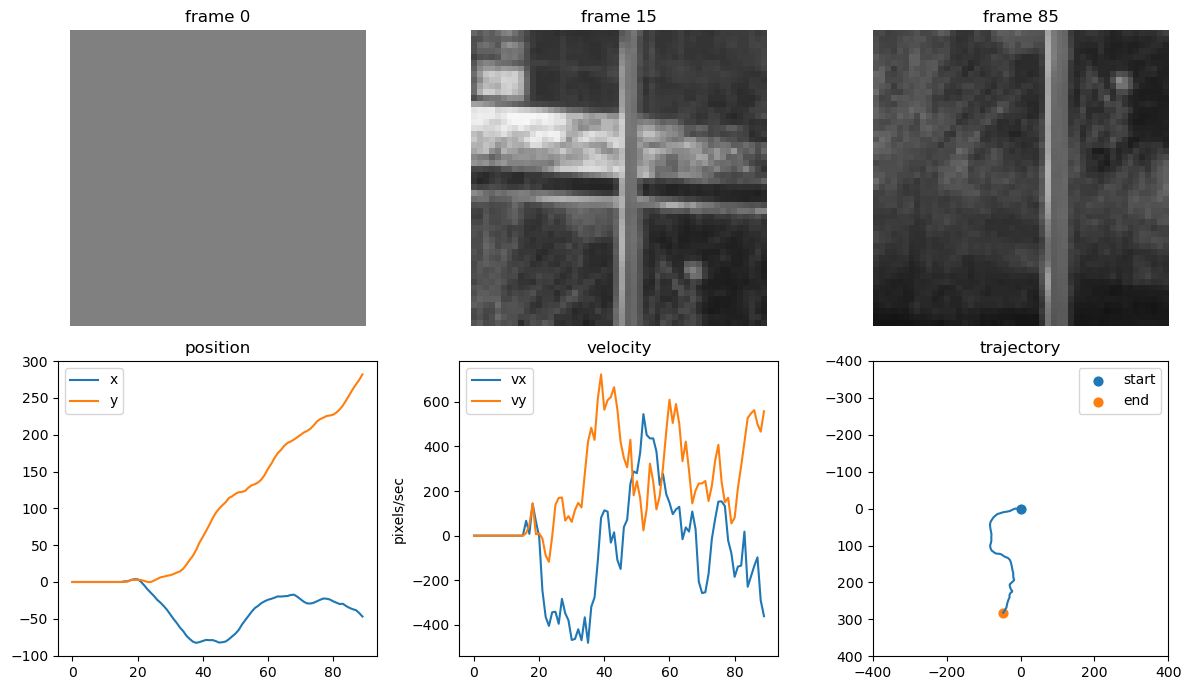

In [3]:
show_one_sample_summary(dataset, 0, frame_indices=[0,15,85])

In [4]:

anim = sample_animation(dataset, 0, viz_fps=20, save_path=None)
display(HTML(anim.to_jshtml()))

# Split/Val sets

In [5]:
import numpy as np
from torch.utils.data import Subset, DataLoader

def split_by_source_image(
    dataset,
    train_frac=0.8,
    val_frac=0.2,
    seed=0,
):
    assert abs(train_frac + val_frac - 1.0) < 1e-8

    # Unique image identities: ("frozen", image_idx), ("running", image_idx)
    image_keys = sorted({
        (meta["source"], meta["image_idx"])
        for meta in dataset.index
    })

    rng = np.random.default_rng(seed)
    image_keys = np.array(image_keys, dtype=object)
    rng.shuffle(image_keys)

    n_total = len(image_keys)
    n_train = int(round(train_frac * n_total))

    train_keys = set(map(tuple, image_keys[:n_train]))
    val_keys = set(map(tuple, image_keys[n_train:]))

    train_indices = []
    val_indices = []

    for i, meta in enumerate(dataset.index):
        key = (meta["source"], meta["image_idx"])

        if key in train_keys:
            train_indices.append(i)
        elif key in val_keys:
            val_indices.append(i)
        else:
            raise RuntimeError("Sample did not match train or val split.")

    train_dataset = Subset(dataset, train_indices)
    val_dataset = Subset(dataset, val_indices)

    return train_dataset, val_dataset, train_keys, val_keys

In [6]:

train_dataset, val_dataset, train_keys, val_keys = split_by_source_image(
    dataset,
    train_frac=0.8,
    val_frac=0.2,
    seed=0,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,
)

print("Total samples:", len(dataset))
print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))

print("Train images:", len(train_keys))
print("Val images:", len(val_keys))

print("Overlap:", len(train_keys & val_keys))

Total samples: 1950
Train samples: 1560
Val samples: 390
Train images: 260
Val images: 65
Overlap: 0


## Build NN

In [ ]:
NUM_NEURONS = 8
HEIGHT = 50
WIDTH = 50
MAX_DELAY = 50


In [ ]:
class CNN(nn.Module):
    """
    A convolutional neural network (CNN) model for RGC. The model consists 
    of a series of convolutional layers followed by a fully connected layer 
    to produce the mean of a Poisson spike count distribution. The model also 
    includes a nonlinear activation function between layers to capture nonlinear 
    features of the stimulus.

    Parameters
    ----------
    num_neurons : int
        The number of OUTPUT neurons in the model.
    height : int
        The height of the stimulus in pixels.
    width : int
        The width of the stimulus in pixels.
    max_delay : int
        The maximum delay in frames for the temporal convolution.
    rf_size_1 : int
        The size of the receptive field for the first layer.
    rf_size_2 : int
        The size of the receptive field for the second layer.
    num_subunits_1 : int
        The number of subunits in the first layer.
    num_subunits_2 : int
        The number of subunits in the second layer.
    mean_function : callable
        The function to compute the mean of the Poisson distribution.
    initial_bias : float
        The initial bias for the temporal convolution.
    spatial_conv : nn.Conv2d
        The convolutional layer for the spatial convolution.
    temporal_conv : nn.Conv1d
        The convolutional layer for the temporal convolution.
    layer2 : nn.Conv2d
        The convolutional layer for the second layer.
    layer3 : nn.Linear
        The fully connected layer for the output.
    """
    num_neurons: int
    height: int
    width: int
    max_delay: int
    rf_size_1: int
    rf_size_2: int
    num_subunits_1: int
    num_subunits_2: int
    mean_function: callable
    spatial_conv: nn.Conv2d
    temporal_conv: nn.Conv1d
    layer2: nn.Conv2d
    layer3: nn.Linear

    def __init__(self,
                 num_neurons: int = 8,
                 height: int = 50,
                 width: int = 50,
                 rf_size_1: int = 15,
                 rf_size_2: int = 11,
                 max_delay: int = 50,
                 num_subunits_1: int = 8,
                 num_subunits_2: int = 8,
                 initial_bias: float = 0.05,
                 mean_function: callable = F.softplus):

        super().__init__()
        self.num_neurons = num_neurons
        self.height = height
        self.width = width
        self.max_delay = max_delay
        self.rf_size_1 = rf_size_1
        self.rf_size_2 = rf_size_2
        self.num_subunits_1 = num_subunits_1
        self.num_subunits_2 = num_subunits_2
        self.mean_function = mean_function

        # ---- 1a. First spatial conv (rank-1 spatial part) ----
        # [T, 1, H, W] -> [T, N1, H1, W1]
        self.spatial_conv = nn.Conv2d(
            in_channels=1,
            out_channels=num_subunits_1,
            kernel_size=rf_size_1,
            padding=0,           # valid conv
            bias=True,
        )

        # Compute spatial sizes after conv1 (valid padding)
        H1 = height - rf_size_1 + 1
        W1 = width - rf_size_1 + 1
        self.H1 = H1
        self.W1 = W1

        # ---- 1b. Temporal conv (rank-1 temporal part) ----
        # We want a per-subunit temporal filter, shared across space:
        # input to Conv1d: [batch=H1*W1, C=N1, T]
        # groups=N1 => one temporal filter per subunit
        self.temporal_conv = nn.Conv1d(
            in_channels=num_subunits_1,
            out_channels=num_subunits_1,
            kernel_size=max_delay,
            groups=num_subunits_1,
            bias=True,
        )

        # ---- 2a. Second spatial conv + mixing ----
        # [T, N1, H1, W1] -> [T, N2, H2, W2]
        self.layer2 = nn.Conv2d(
            in_channels=num_subunits_1,
            out_channels=num_subunits_2,
            kernel_size=rf_size_2,
            padding=0,
            bias=True,
        )

        # Spatial sizes after second conv
        H2 = H1 - rf_size_2 + 1
        W2 = W1 - rf_size_2 + 1
        self.H2 = H2
        self.W2 = W2

        # ---- 3a. Linear readout from N2 × H2 × W2 to N neurons ----
        self.layer3 = nn.Linear(num_subunits_2 * H2 * W2, num_neurons)

        # inverse softplus of initial_rate
        bias = torch.log(torch.exp(torch.tensor(float(initial_bias))) - 1.0)
        nn.init.constant_(self.layer3.bias, bias)

    def forward(
        self,
        movie):
        """
        movie: (B, T, 1, H, W)
        returns: rates, shape (B, T, num_neurons)
        """
        B, T, C, H, W = movie.shape

        # -------------------------------------------------------
        # 1. Spatial conv per frame
        # -------------------------------------------------------
        x = movie.reshape(B * T, C, H, W)          # (B*T, 1, H, W)
        x = self.spatial_conv(x)                  # (B*T, N1, H1, W1)

        _, N1, H1, W1 = x.shape
        
        #restore Batch over time 
        x = x.reshape(B, T, N1, H1, W1)           # (B, T, N1, H1, W1)
        
        # -------------------------------------------------------
        # 2. Tempo conv at each spatial location
        # -------------------------------------------------------
        #NOTE: tempconv expects (B, C, T)
        x = x.permute(0, 3, 4, 2, 1)              # (B, H1, W1, N1, T)
        x = x.reshape(B * H1 * W1, N1, T)         # (B*H1*W1, N1, T)

        # Causal padding: prediction at time t only sees current/past frames
        x = F.pad(x, (self.max_delay - 1, 0))     # (B*H1*W1, N1, T+delay-1)
        x = self.temporal_conv(x)                 # (B*H1*W1, N1, T)

        # Back to movie-like tensor
        x = x.reshape(B, H1, W1, N1, T)
        x = x.permute(0, 4, 3, 1, 2)              # (B, T, N1, H1, W1)

        x = F.relu(x)
        
        # -------------------------------------------------------
        # 3. 2nd spatial conv 
        # -------------------------------------------------------
        
        x = x.reshape(B * T, N1, H1, W1)          # (B*T, N1, H1, W1)
        x = self.layer2(x)                        # (B*T, N2, H2, W2)
        x = F.relu(x)

        _, N2, H2, W2 = x.shape
        
        ## -------------------------------------------------------
        # 4. Linear readout to neurons
        # -------------------------------------------------------
        x = x.reshape(B * T, N2 * H2 * W2)  # (B*T, features)
        drive = self.layer3(x)                 # (B*T, num_neurons)
        rates = self.mean_function(drive)         # (B*T, num_neurons)
        
        rates = rates.reshape(B, T, self.num_neurons)  # (B, T, num_neurons)
        return rates + 1e-8  # add small constant for numerical stability

In [20]:
class LinearVelocityDecoder(nn.Module):
    def __init__(self, num_neurons, out_dim=2):
        super().__init__()
        self.decoder = nn.Linear(num_neurons, out_dim)

    def forward(self, rates):
        return self.decoder(rates)
    
    
class RetinaVelocityModel(nn.Module):
    def __init__(self, retina, num_neurons):
        super().__init__()
        self.retina = retina
        self.decoder = LinearVelocityDecoder(num_neurons=num_neurons, out_dim=2)

    def forward(self, movie, return_rates=False):
        rates = self.retina(movie)          # (B, T, N)
        pred_vel = self.decoder(rates)      # (B, T, 2)

        if return_rates:
            return pred_vel, rates

        return pred_vel

In [23]:
retina = CNN(
    num_neurons=8,
    height=50,
    width=50,
    rf_size_1=15,
    rf_size_2=11,
    max_delay=15,
    num_subunits_1=8,
    num_subunits_2=8,
    initial_bias=0.05,
    mean_function=F.softplus,
)

model = RetinaVelocityModel(
    retina=retina,
    num_neurons=8,
).to(device)

In [24]:
batch = next(iter(train_loader))
movie = batch["movie"].to(device)

with torch.no_grad():
    pred_vel, rates = model(movie, return_rates=True)

print("movie:", movie.shape)
print("pred_vel:", pred_vel.shape)
print("rates:", rates.shape)
print("rates min/max:", rates.min().item(), rates.max().item())

movie: torch.Size([16, 90, 1, 50, 50])
pred_vel: torch.Size([16, 90, 2])
rates: torch.Size([16, 90, 8])
rates min/max: 0.041154585778713226 0.055020567029714584


## Loss

In [25]:
def compute_velocity_stats(loader, gray_frames, key="scene_vel", device="cpu"):
    sum_v = torch.zeros(2, device=device)
    sum_v2 = torch.zeros(2, device=device)
    n = 0

    for batch in loader:
        v = batch[key].to(device)          # (B, T, 2)
        v = v[:, gray_frames:, :]          # remove gray prelude
        v = v.reshape(-1, 2)

        sum_v += v.sum(dim=0)
        sum_v2 += (v ** 2).sum(dim=0)
        n += v.shape[0]

    mean = sum_v / n
    var = sum_v2 / n - mean ** 2
    std = torch.sqrt(var + 1e-8)

    return mean, std

gray_frames = dataset.gray_frames  # probably 15

vel_mean, vel_std = compute_velocity_stats(
    train_loader,
    gray_frames=gray_frames,
    key="scene_vel",
    device=device,
)

print("vel_mean:", vel_mean)
print("vel_std:", vel_std)

def velocity_decoding_loss(
    pred_vel_z,
    target_vel,
    rates,
    vel_mean,
    vel_std,
    gray_frames,
    rate_penalty=1e-4,
):
    """
    pred_vel_z : (B, T, 2)
        Predicted normalized velocity.

    target_vel : (B, T, 2)
        Target velocity in raw units, e.g. px/s.

    rates : (B, T, N)
        Nonnegative artificial neural rates.

    vel_mean, vel_std : (2,)
        Training-set velocity normalization statistics.

    gray_frames : int
        Number of prepended gray frames to exclude from velocity loss.

    rate_penalty : float
        Weak penalty on mean firing rate.
    """

    target_vel_z = (target_vel - vel_mean) / vel_std

    loss_vel = (
        (pred_vel_z[:, gray_frames:] - target_vel_z[:, gray_frames:]) ** 2
    ).mean()

    loss_rate = rates[:, gray_frames:].mean()

    loss = loss_vel + rate_penalty * loss_rate

    return loss, {
        "loss_vel": loss_vel.detach(),
        "loss_rate": loss_rate.detach(),
        "loss_total": loss.detach(),
    }

KeyboardInterrupt: 

In [ ]:
batch = next(iter(train_loader))

movie = batch["movie"].to(device)
target = batch["scene_vel"].to(device)

pred_vel_z, rates = model(movie, return_rates=True)

loss, metrics = velocity_decoding_loss(
    pred_vel_z=pred_vel_z,
    target_vel=target,
    rates=rates,
    vel_mean=vel_mean,
    vel_std=vel_std,
    gray_frames=gray_frames,
    rate_penalty=1e-4,
)

print("loss:", loss.item())
print("velocity loss:", metrics["loss_vel"].item())
print("rate loss:", metrics["loss_rate"].item())